## Karhunen-Loève Decomposition

In [1]:
from cd.algs.kl_decomp import KLDecomp

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [26]:
n = 1000
N = 50
C = 3

t = np.linspace(0, 2*np.pi, N)
x = np.zeros((n, N, C))

frequencies = [1, 2, 3]  # different freq per channel
#phases = [0, np.pi/4, np.pi/2]
phases = np.random.rand(n, 3) * 2 * np.pi

for i in range(n):
    for ch in range(C):
        x[i, :, ch] = np.sin(frequencies[ch]*t + phases[i, ch]) + 0.01*np.random.randn(N)
x.shape

(1000, 50, 3)

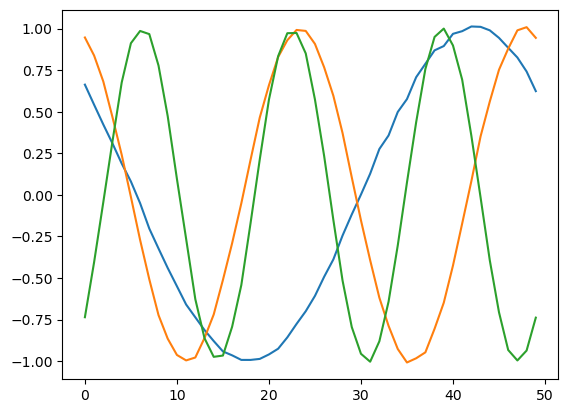

In [27]:
plt.plot(x[3])

In [33]:
model = KLDecomp(0.8).fit(x)
model.components_.shape

(5, 150)

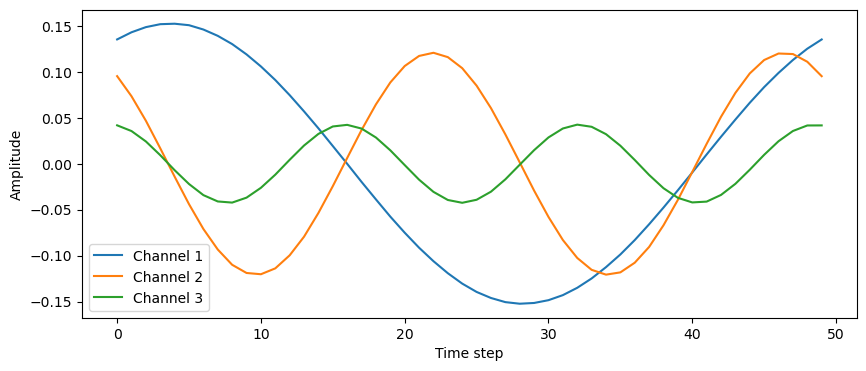

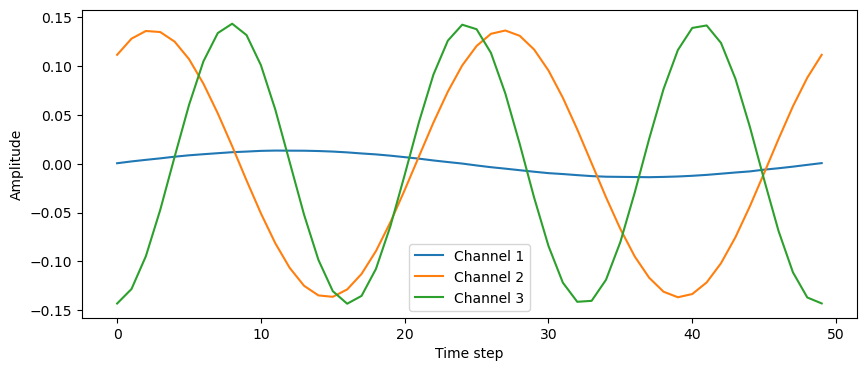

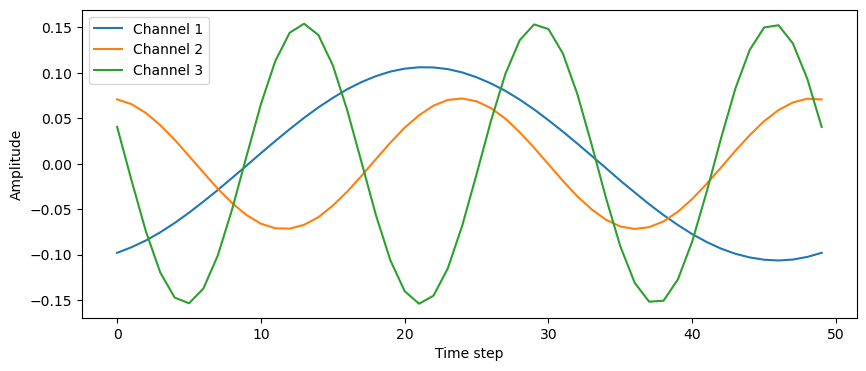

In [35]:
components = model.components_

for i in range(3):
    comp = components[i].reshape(N, C, order='A')
    plt.figure(figsize=(10, 4))
    for ch in range(C):
        plt.plot(comp[:, ch], label=f'Channel {ch+1}')
    plt.xlabel('Time step')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()